# show the statistics of umineko data, including the labels

In [ ]:
# 展示label种类和数量
# 展示年份差异
# 展示back差异

In [1]:
import pandas as pd
import numpy as np
import random
import torch
from tqdm import tqdm
from torch import optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from umap import UMAP
import plotly.express as px
from deepview.calculate_results.data.umineko.umineko_data import (
    read_umineko_path,
    extract_data_from_year_back,
    label_dict,
)

from deepview.calculate_results.models.utils import (
    sliding_window,
    data_loader_umineko,
    MSEloss_weighted,
    MSEloss,
    # torch,
    AE_eval_time_series,
    AE_train_time_series_resnet,
    # np,
    # tqdm
    Autoencoder3d,
    plot_reconstruction_result,
majority_value,
)
def set_random_seed(seed):
    # Set seed for Python's random module
    random.seed(seed)

    # Set seed for NumPy
    np.random.seed(seed)

    # Set seed for PyTorch
    torch.manual_seed(seed)

    # If using CUDA, set seed for GPU as well
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

# Set a fixed random seed
seed_value = 2025
set_random_seed(seed_value)

def gaussian_std(X):
    mean_val = np.mean(X.astype(float), axis=0)
    std_val = np.std(X.astype(float), axis=0)
    X_standardized = (X - mean_val) / np.maximum(std_val, 10 ** -5)
    return X_standardized

In [2]:
raw_data, labeled_data = [], []
for year in ['2018', '2019', '2022']:
    dp = r'D:\code\DeepView\deepview\calculate_results\data\umineko_%s.npy'
    data = np.load(dp % year, allow_pickle=True).item()
    # Access the individual components
    raw_ = data['raw_data']
    labeled_ = data['labeled_data']
    if year=='2018':
        df_raw_2018 = raw_
        df_2018 = labeled_
    elif year=='2019':
        df_raw_2019 = raw_
        df_2019 = labeled_
    elif year=='2022':
        df_raw_2022 = raw_
        df_2022 = labeled_
    else:
        print('Error: year not found')
        break

In [5]:
df_2022.tail(3)

,datetime,unixtime,logger_id,animal_tag,acc_x,acc_y,acc_z,latitude,longitude,gps_status,...,temperature,activity_class,label,year,back,species,timestamp,label_id,GPS_velocity,GPS_bearing
210710,1.652764e+18,1.652764e+09,lbs0004,LB09,0.009219,-0.637344,1.756563,NaN,NaN,NaN,...,NaN,NaN,flying_passive,2022.0,1.0,umineko,2022-05-17T05:10:54.439Z,2.0,NaN,NaN
210711,1.652764e+18,1.652764e+09,lbs0004,LB09,0.007813,-0.240781,2.070625,NaN,NaN,NaN,...,NaN,NaN,flying_passive,2022.0,1.0,umineko,2022-05-17T05:10:54.479Z,2.0,NaN,NaN
210712,1.652764e+18,1.652764e+09,lbs0004,LB09,0.047031,-0.168281,1.779687,NaN,NaN,NaN,...,NaN,NaN,flying_passive,2022.0,1.0,umineko,2022-05-17T05:10:54.519Z,2.0,NaN,NaN


# number of labels

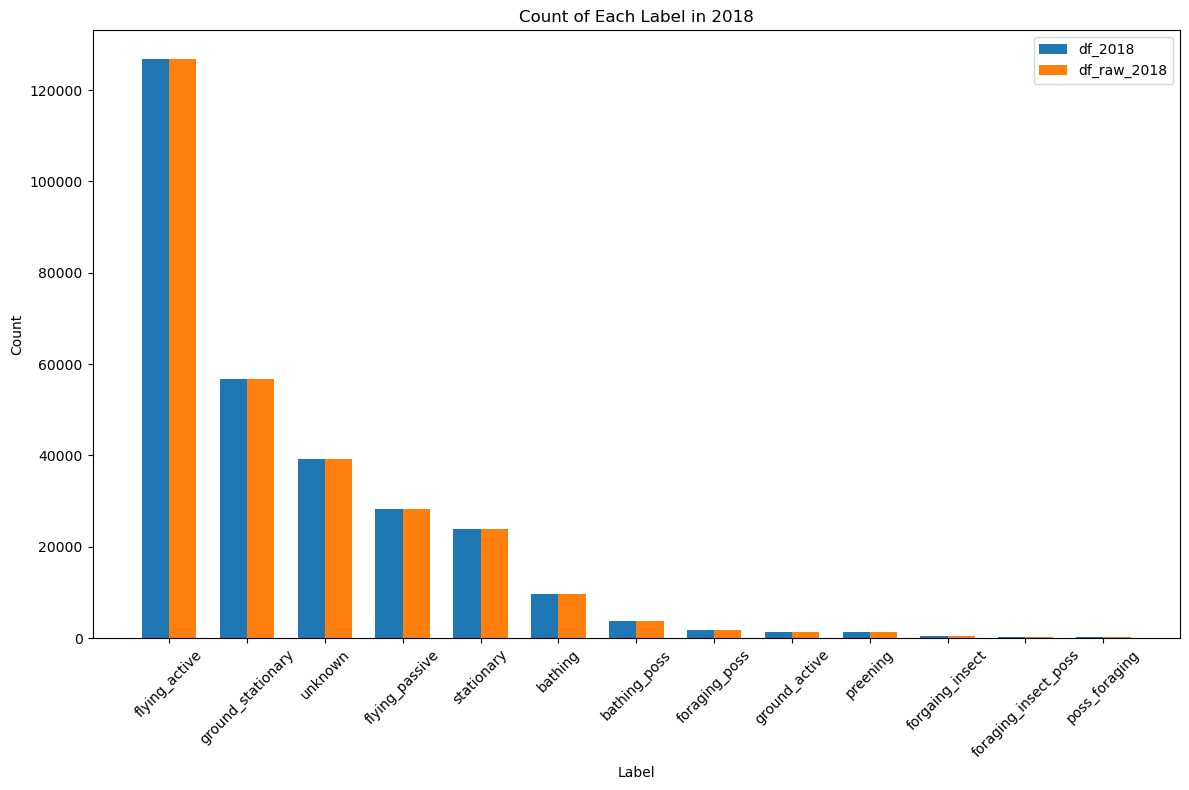

In [13]:
# Count the number of each unique value in the 'label' column
label_counts_2018 = df_2018['label'].value_counts()
label_counts_raw_2018 = df_raw_2018['label'].value_counts()

# Create a DataFrame to hold the counts for both df_2018 and df_raw_2018
combined_counts = pd.DataFrame({
    'df_2018': label_counts_2018,
    'df_raw_2018': label_counts_raw_2018
}).fillna(0)

# Plot a bar chart with two bars for each label
labels = combined_counts.index
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 8))
bars1 = ax.bar(x - width/2, combined_counts['df_2018'], width, label='df_2018')
bars2 = ax.bar(x + width/2, combined_counts['df_raw_2018'], width, label='df_raw_2018')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_title('Count of Each Label in 2018')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()

fig.tight_layout()
plt.show()

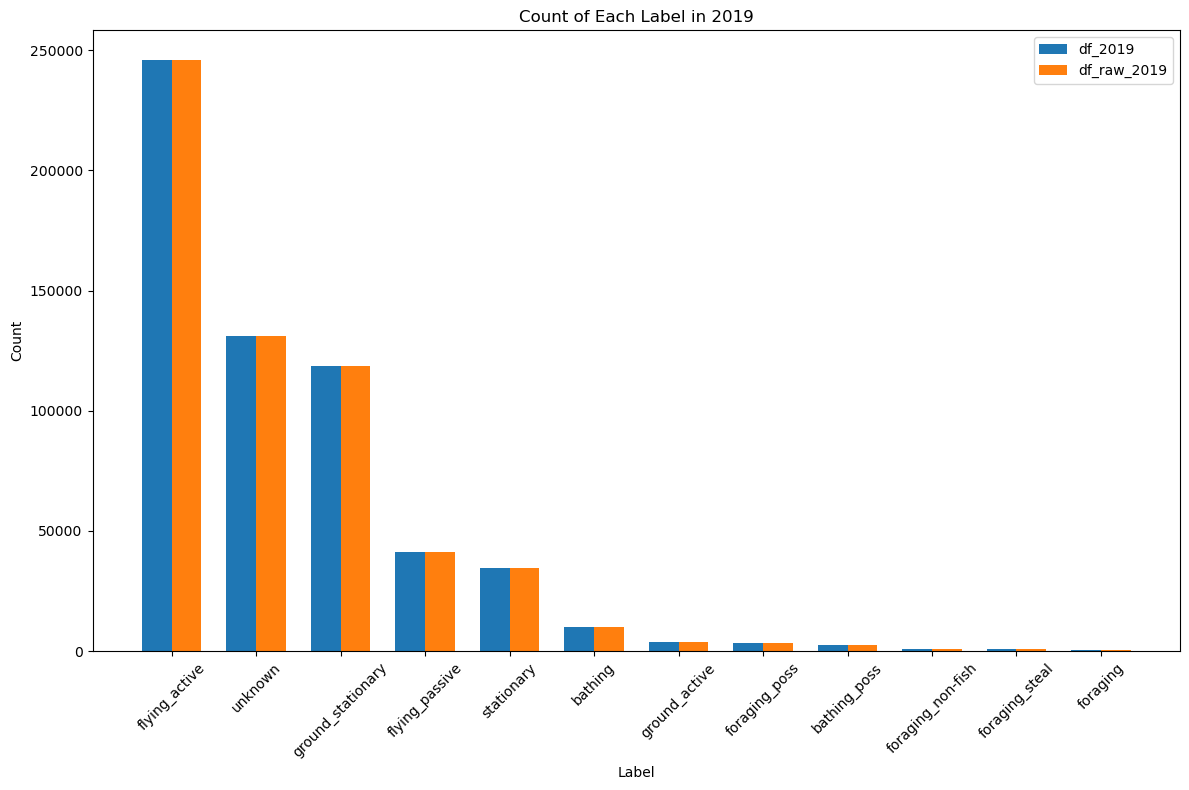

In [20]:
# Count the number of each unique value in the 'label' column
label_counts_2019 = df_2019['label'].value_counts()
label_counts_raw_2019 = df_raw_2019['label'].value_counts()

# Create a DataFrame to hold the counts for both df_2018 and df_raw_2018
combined_counts = pd.DataFrame({
    'df_2019': label_counts_2019,
    'df_raw_2019': label_counts_raw_2019
}).fillna(0)

# Plot a bar chart with two bars for each label
labels = combined_counts.index
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 8))
bars1 = ax.bar(x - width/2, combined_counts['df_2019'], width, label='df_2019')
bars2 = ax.bar(x + width/2, combined_counts['df_raw_2019'], width, label='df_raw_2019')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_title('Count of Each Label in 2019')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()

fig.tight_layout()
plt.show()

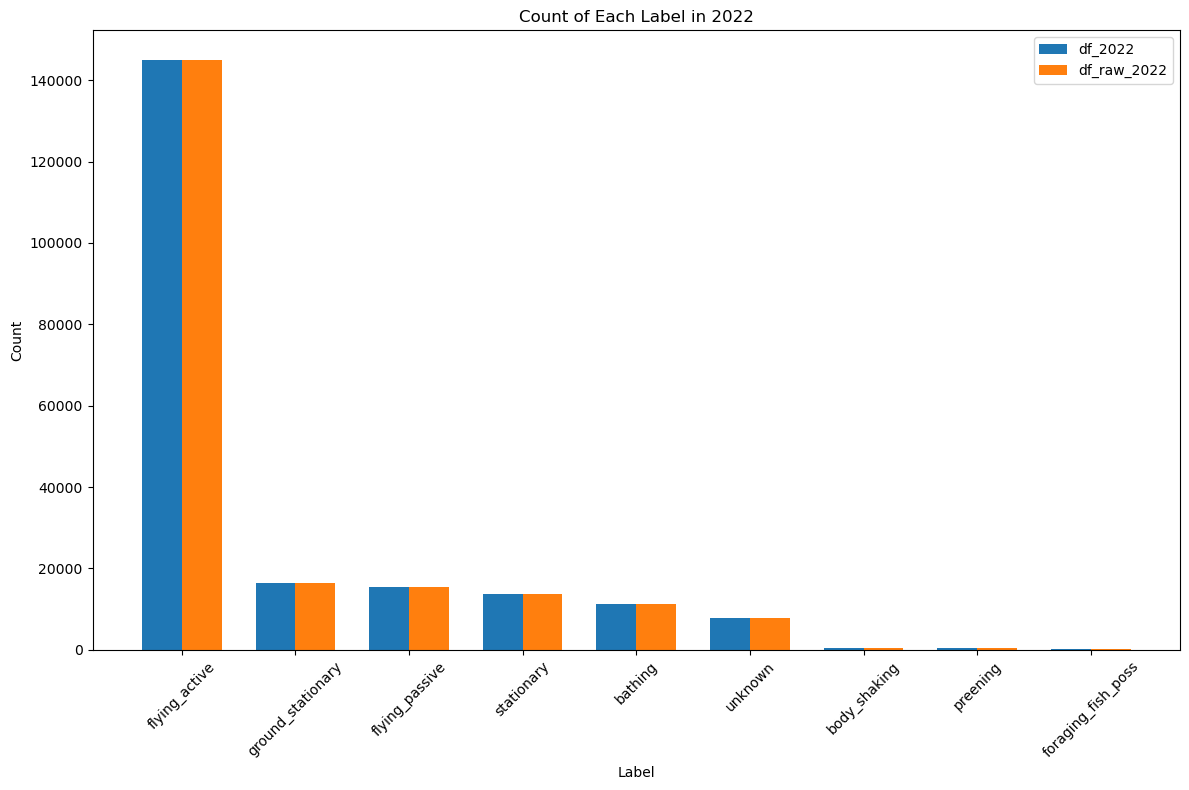

In [16]:
# Count the number of each unique value in the 'label' column
label_counts_2022 = df_2022['label'].value_counts()
label_counts_raw_2022 = df_raw_2022['label'].value_counts()

# Create a DataFrame to hold the counts for both df_2022 and df_raw_2022
combined_counts = pd.DataFrame({
    'df_2022': label_counts_2022,
    'df_raw_2022': label_counts_raw_2022
}).fillna(0)

# Plot a bar chart with two bars for each label
labels = combined_counts.index
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 8))
bars1 = ax.bar(x - width/2, combined_counts['df_2022'], width, label='df_2022')
bars2 = ax.bar(x + width/2, combined_counts['df_raw_2022'], width, label='df_raw_2022')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_title('Count of Each Label in 2022')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()

fig.tight_layout()
plt.show()

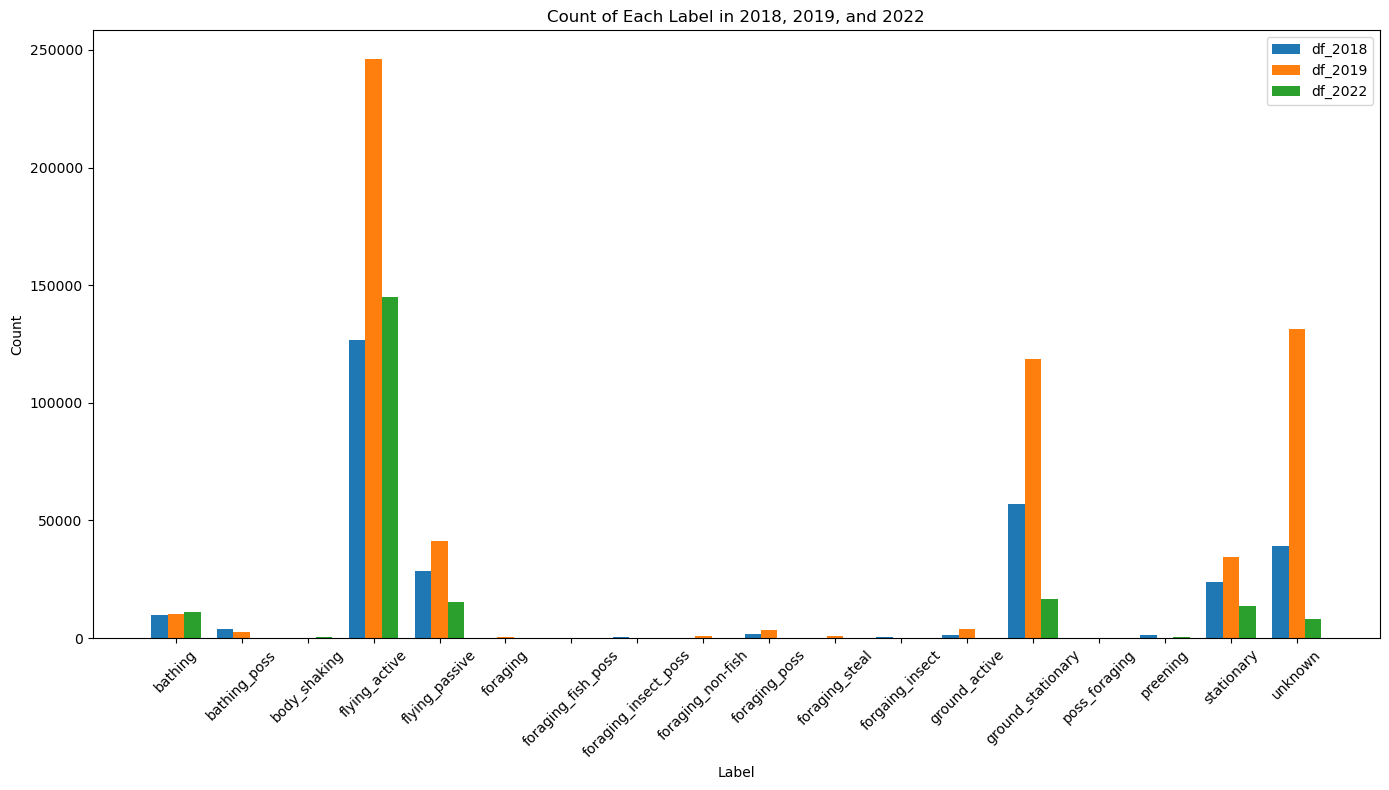

In [21]:
# Count the number of each unique value in the 'label' column
label_counts_2018 = df_2018['label'].value_counts()
label_counts_2019 = df_2019['label'].value_counts()
label_counts_2022 = df_2022['label'].value_counts()

# Create a DataFrame to hold the counts for df_2018, df_2019, and df_2022
combined_counts = pd.DataFrame({
    'df_2018': label_counts_2018,
    'df_2019': label_counts_2019,
    'df_2022': label_counts_2022
}).fillna(0)

# Plot a bar chart with three bars for each label
labels = combined_counts.index
x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars

fig, ax = plt.subplots(figsize=(14, 8))
bars1 = ax.bar(x - width, combined_counts['df_2018'], width, label='df_2018')
bars2 = ax.bar(x, combined_counts['df_2019'], width, label='df_2019')
bars3 = ax.bar(x + width, combined_counts['df_2022'], width, label='df_2022')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_title('Count of Each Label in 2018, 2019, and 2022')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()

fig.tight_layout()
plt.show()

# latent space of the accelerometer data

In [36]:
selected_df = pd.concat([df_raw_2018, df_raw_2019, df_raw_2022], ignore_index=True)
year_id = np.concatenate([np.zeros(len(df_raw_2018)), np.ones(len(df_raw_2019)), np.ones(len(df_raw_2022)) * 2])

selected_df['label_id'] = selected_df['label'].map(label_dict)
selected_df['label_id'] = selected_df['label_id'].fillna(-2)

device = 'cuda'
len_sw = 50
sensor_type = 'accel'

activity_label = True
if activity_label:
    selected_columns = ['acc_x', 'acc_y', 'acc_z', 'label_id', 'animal_tag']  # without timestamps
  # without timestamps，activity labels
else:
    selected_df['animal_tag_id'] = pd.factorize(selected_df['animal_tag'])[0]
    selected_columns = ['acc_x', 'acc_y', 'acc_z', 'animal_tag_id', 'label_id']  # without timestamps
  # 将animal tag作为label，判断鸟的embedding是否分开

selected_np = selected_df[selected_columns].values

############################################
data_np = selected_np[:, :-2]
tmp_b_stand = gaussian_std(data_np)

##########################################

selected_np[:, :-2] = tmp_b_stand

tmp_b = sliding_window(selected_np[:, :-1], len_sw, len_sw)
# concatenate list
data_b = np.transpose(tmp_b[:, :, :-1], (0, 2, 1))  # [B, Len, dim-1] -> [B, dim-1, Len]
label_b = tmp_b[:, :, -1]  # [B, Len]
year_b = sliding_window(np.concatenate([tmp_b_stand, year_id.reshape(-1,1)],axis=1), len_sw, len_sw)[:, 0, -1]  # [B]

batch_size = 1024
train_set_r = data_loader_umineko(data_b.astype(float), label_b.astype(int), device=device)
train_loader = DataLoader(train_set_r, batch_size=batch_size,
                          shuffle=False, drop_last=False)


In [23]:
selected_df['label'].unique()

array([<NA>, 'ground_stationary', 'unknown', 'flying_active',
       'flying_passive', 'stationary', 'bathing_poss', 'bathing',
       'preening', 'foraging_insect_poss', 'ground_active',
       'foraging_poss', 'forgaing_insect', 'poss_foraging',
       'foraging_non-fish', 'foraging', 'foraging_steal', nan,
       'foraging_fish_poss', 'body_shaking'], dtype=object)

In [ ]:
model = Autoencoder3d()
model = model.to(device)
criterion = MSEloss()

criterion = criterion.to(device)

learning_rate = 0.001
# training
start_epoch = 0
num_epochs = 1000

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
# learning rate update per epoch

training_loss = []
for epoch in tqdm(range(start_epoch, num_epochs)):

    losses = AE_train_time_series_resnet(train_loader, model, criterion, optimizer, epoch, scheduler, device)
    training_loss.append(np.average(losses))
    if (epoch % 100 == 0) or (epoch == num_epochs - 1):
        # Print the learning rate
        for param_group in optimizer.param_groups:
            print("Learning Rate:", param_group['lr'])
        #     print('loss of the ' + str(epoch) + '-th training epoch is :' + losses.__str__())
        # reconstruction result
        representation_list, sample_list, pred_list, label_list = \
            AE_eval_time_series(train_loader, model, device)
        plot_reconstruction_result(representation_list, sample_list, pred_list, label_list, 'train_epoch_%s' % str(epoch))

In [18]:
print('Saving model at: ' + 'AE_reconstruct_epoch%s' % str(epoch) \
      + '_datalen%s_' % str(len_sw) + sensor_type + '.pth')
torch.save(model.state_dict(), 'AE_reconstruct_epoch%s' % str(epoch) + '_datalen%s_' % str(len_sw) + sensor_type + '.pth')
# T_max=50, lr=0.0001, epoch=623

Saving model at: AE_reconstruct_epoch623_datalen50_accel.pth


In [21]:
print('Saving model at: ' + 'AE_reconstruct_epoch%s' % str(epoch) \
      + '_datalen%s_' % str(len_sw) + sensor_type + '.pth')
torch.save(model.state_dict(), 'AE_reconstruct_epoch%s' % str(epoch) + '_datalen%s_' % str(len_sw) + sensor_type + '.pth')
# T_max=maxepoch, lr=0.001, epoch=826

826

In [41]:
def AE_eval_time_series(train_loader, model, device, memotimes=30):
    model.eval()

    representation_list = []
    sample_list, timestamp_list, label_list, pred_list, timestr_list, flag_list = [], [], [], [], [], []
    for i, (sample, label) in enumerate(train_loader):

        sample = sample.to(device=device, non_blocking=True, dtype=torch.float)
        # input of autoencoder will be 3D, the backbone is 1d-cnn
        x_encoded, output = model(sample)  # x_encoded
        tmp_representation = x_encoded.detach().cpu().numpy()
        representation_list.append(tmp_representation)
        sample_list.append(sample.detach().cpu().numpy())
        label_list.append(label.detach().cpu().numpy())
        pred_list.append(output.detach().cpu().numpy())

    return representation_list, sample_list, pred_list, label_list

In [ ]:
representation_list, sample_list, pred_list, label_list = \
            AE_eval_time_series(train_loader, model, device)


In [43]:
sample_concat = np.concatenate(sample_list)
sample_concat.shape

(702274, 3, 50)

In [44]:
# representation_list, sample_list, pred_list, label_list = \
#             AE_eval_time_series(train_loader, model, device)
repre_concat = np.concatenate(representation_list)
repre_reshape = repre_concat.reshape(repre_concat.shape[0], -1)
    
umap_3d = UMAP(n_components=3)
proj_3d_gyro = umap_3d.fit_transform(repre_reshape)

label_concat = np.concatenate(label_list)
label_concat_vote = majority_value(label_concat)

labeldict_findstr = {-2:'unknown',
                     0:'stationary',
                     1:'bathing',
                     7:'forgaing_insect',
                     2:'flying',
                     3:'flight_cruising',
                     4:'flight_take_off',
                     5:'foraging',
                     6:'foraging_fish_poss',
                     8:'foraging_non-fish',
                     9:'foraging_steal',
                     10:'foraging_dive',
                     11:'surface_seizing',
                     12:'body_shaking',
                     13:'ground_active'}
label_concat_vote_str = [labeldict_findstr[i] for i in label_concat_vote]

fig_3d = px.scatter_3d(
    proj_3d_gyro, x=0, y=1, z=2,
    color=label_concat_vote_str,
    labels={'color': 'activity'},
    color_discrete_map={'unknown': 'lightgrey'},
)
# Reduce marker size for all points
for trace in fig_3d.data:
    trace.marker.size = 6  # Adjust the size to your preference (e.g., 6)

# Update transparency for traces where activity is '-2.0'
fig_3d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())
fig_3d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point
fig_3d.write_html("3dt.html")

#############################################################
umap_2d = UMAP(n_components=2)
proj_2d_gyro = umap_2d.fit_transform(repre_reshape)
fig_2d = px.scatter(
    proj_2d_gyro, x=0, y=1,
    color=label_concat_vote_str,
    labels={'color': 'activity'},
    color_discrete_map={'unknown': 'lightgrey'},
)
# Reduce marker size for all points
for trace in fig_2d.data:
    trace.marker.size = 6 
    
# Update transparency for traces where activity is '-2.0'
fig_2d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())
fig_2d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point
fig_2d.write_html("2dt.html")


In [47]:
proj_3d_gyro.shape

(702274, 3)

In [48]:

umap_3d = UMAP(n_components=3)
proj_3d_gyro = umap_3d.fit_transform(repre_reshape)

# label_concat = np.concatenate(year_b)
# label_concat_vote = majority_value(label_concat)

labeldict_findstr = {0:'umineko2018',
                     1:'umineko2019',
                     2:'umineko2022',}
label_concat_vote_str = [labeldict_findstr[i] for i in year_b]

fig_3d = px.scatter_3d(
    proj_3d_gyro, x=0, y=1, z=2,
    color=label_concat_vote_str,
    labels={'color': 'year'},
    color_discrete_map={'unknown': 'lightgrey'},
)
# Reduce marker size for all points
for trace in fig_3d.data:
    trace.marker.size = 6  # Adjust the size to your preference (e.g., 6)

# Update transparency for traces where activity is '-2.0'
fig_3d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())
fig_3d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point
fig_3d.write_html("3dty.html")

#############################################################
umap_2d = UMAP(n_components=2)
proj_2d_gyro = umap_2d.fit_transform(repre_reshape)
fig_2d = px.scatter(
    proj_2d_gyro, x=0, y=1,
    color=label_concat_vote_str,
    labels={'color': 'year'},
    color_discrete_map={'unknown': 'lightgrey'},
)
# Reduce marker size for all points
for trace in fig_2d.data:
    trace.marker.size = 6 
    
# Update transparency for traces where activity is '-2.0'
fig_2d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())
fig_2d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point
fig_2d.write_html("2dty.html")


In [49]:
full_model_path = r'D:\code\DeepView\deepview\calculate_results\data\umineko\AE_reconstruct_epoch623_datalen50_accel.pth'
if torch.cuda.is_available():
    model.load_state_dict(torch.load(full_model_path, weights_only=False))
else:
    model.load_state_dict(torch.load(full_model_path, weights_only=False, map_location=torch.device('cpu')))


In [51]:
representation_list, sample_list, pred_list, label_list = \
            AE_eval_time_series(train_loader, model, device)
repre_concat = np.concatenate(representation_list)
repre_reshape = repre_concat.reshape(repre_concat.shape[0], -1)
    
umap_3d = UMAP(n_components=3)
proj_3d_gyro = umap_3d.fit_transform(repre_reshape)

label_concat = np.concatenate(label_list)
label_concat_vote = majority_value(label_concat)
labeldict_findstr = {-2:'unknown',
                     0:'stationary',
                     1:'bathing',
                     7:'forgaing_insect',
                     2:'flying',
                     3:'flight_cruising',
                     4:'flight_take_off',
                     5:'foraging',
                     6:'foraging_fish_poss',
                     8:'foraging_non-fish',
                     9:'foraging_steal',
                     10:'foraging_dive',
                     11:'surface_seizing',
                     12:'body_shaking',
                     13:'ground_active'}
label_concat_vote_str = [labeldict_findstr[i] for i in label_concat_vote]

fig_3d = px.scatter_3d(
    proj_3d_gyro, x=0, y=1, z=2,
    color=label_concat_vote_str,
    labels={'color': 'activity'},
    color_discrete_map={'unknown': 'lightgrey'},
)
# Reduce marker size for all points
for trace in fig_3d.data:
    trace.marker.size = 6  # Adjust the size to your preference (e.g., 6)

# Update transparency for traces where activity is '-2.0'
fig_3d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())
fig_3d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point
fig_3d.write_html("3dt-623.html")

#############################################################
umap_2d = UMAP(n_components=2)
proj_2d_gyro = umap_2d.fit_transform(repre_reshape)
fig_2d = px.scatter(
    proj_2d_gyro, x=0, y=1,
    color=label_concat_vote_str,
    labels={'color': 'activity'},
    color_discrete_map={'unknown': 'lightgrey'},
)
# Reduce marker size for all points
for trace in fig_2d.data:
    trace.marker.size = 6 
    
# Update transparency for traces where activity is '-2.0'
fig_2d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())
fig_2d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point
fig_2d.write_html("2dt-623.html")


Text(0.5, 1.0, 'Autoencoder_Reconstruct_Umineko_accel_acc_x')

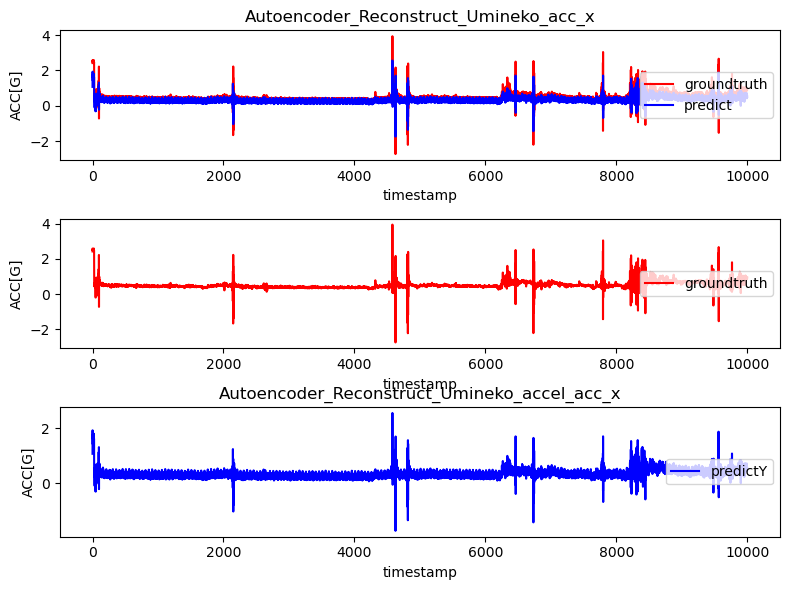

In [58]:
repre_concat = np.concatenate(representation_list)
repre_reshape = repre_concat.reshape(repre_concat.shape[0], -1)

sample_concat = np.concatenate(sample_list)
sample_concat = sample_concat.transpose(0, 2, 1)
sample_reshape = sample_concat.reshape(-1, sample_concat.shape[-1])

pred_concat = np.concatenate(pred_list)
pred_concat = pred_concat.transpose(0, 2, 1)
pred_reshape = pred_concat.reshape(-1, pred_concat.shape[-1])

start = 0
end = min(10000, len(sample_reshape))
col = 0
dict_column = {
    0: 'acc_x',
    1: 'acc_y',
    2: 'acc_z'
}
fig, axes = plt.subplots(3, 1, figsize=(8, 6))
axes[0].plot(sample_reshape[start:end, col], 'r', label='groundtruth')
axes[0].plot(pred_reshape[start:end, col], 'b-', label='predict')
axes[0].set_title('Autoencoder_Reconstruct_Umineko_%s'%dict_column[col])
axes[0].set_xlabel('timestamp')
axes[0].set_ylabel('ACC[G]')
axes[0].legend(loc="right")

axes[1].plot(sample_reshape[start:end, col], 'r', label='groundtruth')
axes[1].set_xlabel('timestamp')
axes[1].set_ylabel('ACC[G]')
axes[1].legend(loc="right")

axes[2].plot(pred_reshape[start:end, col], 'b-', label='predictY')

axes[2].set_xlabel('timestamp')
axes[2].set_ylabel('ACC[G]')
axes[2].legend(loc="right")

# Adjust layout
plt.tight_layout()
plt.title('Autoencoder_Reconstruct_Umineko_accel_%s'%dict_column[col])

Text(0.5, 1.0, 'Autoencoder_Reconstruct_Umineko_accel_acc_y')

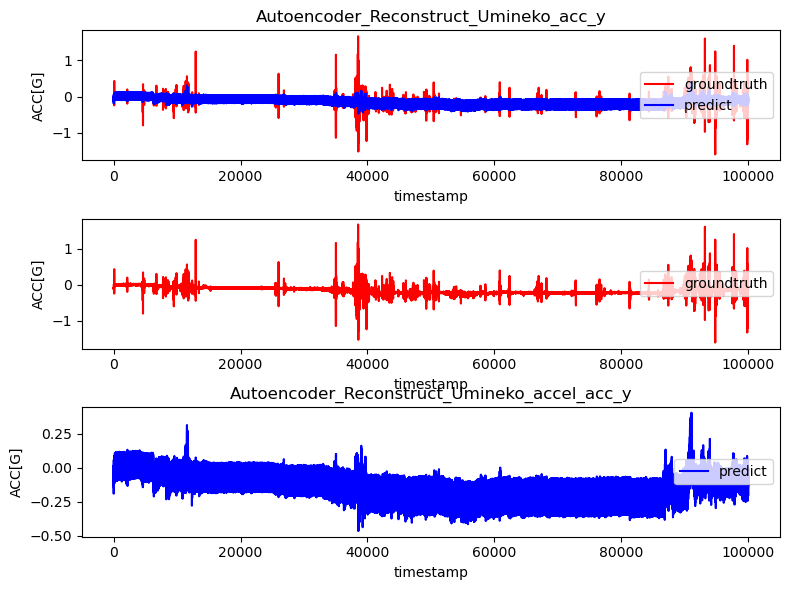

In [60]:

start = 0
end = min(100000, len(sample_reshape))
col = 1
dict_column = {
    0: 'acc_x',
    1: 'acc_y',
    2: 'acc_z'
}
fig, axes = plt.subplots(3, 1, figsize=(8, 6))
axes[0].plot(sample_reshape[start:end, col], 'r', label='groundtruth')
axes[0].plot(pred_reshape[start:end, col], 'b-', label='predict')
axes[0].set_title('Autoencoder_Reconstruct_Umineko_%s'%dict_column[col])
axes[0].set_xlabel('timestamp')
axes[0].set_ylabel('ACC[G]')
axes[0].legend(loc="right")

axes[1].plot(sample_reshape[start:end, col], 'r', label='groundtruth')
axes[1].set_xlabel('timestamp')
axes[1].set_ylabel('ACC[G]')
axes[1].legend(loc="right")

axes[2].plot(pred_reshape[start:end, col], 'b-', label='predict')
axes[2].set_xlabel('timestamp')
axes[2].set_ylabel('ACC[G]')
axes[2].legend(loc="right")

# Adjust layout
plt.tight_layout()
plt.title('Autoencoder_Reconstruct_Umineko_accel_%s'%dict_column[col])

Text(0.5, 1.0, 'Autoencoder_Reconstruct_Umineko_accel_acc_z')

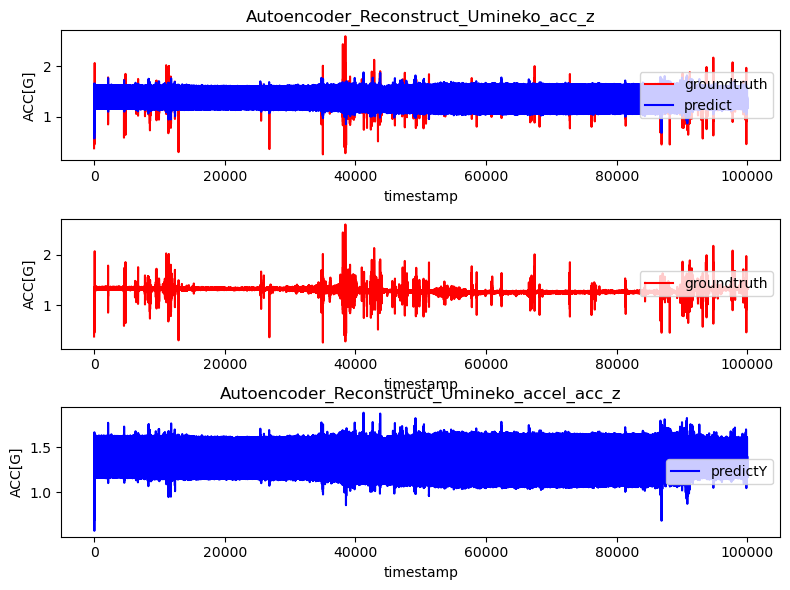

In [61]:
start = 0
end = min(100000, len(sample_reshape))
col = 2
dict_column = {
    0: 'acc_x',
    1: 'acc_y',
    2: 'acc_z'
}
fig, axes = plt.subplots(3, 1, figsize=(8, 6))
axes[0].plot(sample_reshape[start:end, col], 'r', label='groundtruth')
axes[0].plot(pred_reshape[start:end, col], 'b-', label='predict')
axes[0].set_title('Autoencoder_Reconstruct_Umineko_%s'%dict_column[col])
axes[0].set_xlabel('timestamp')
axes[0].set_ylabel('ACC[G]')
axes[0].legend(loc="right")

axes[1].plot(sample_reshape[start:end, col], 'r', label='groundtruth')

axes[1].set_xlabel('timestamp')
axes[1].set_ylabel('ACC[G]')
axes[1].legend(loc="right")


axes[2].plot(pred_reshape[start:end, col], 'b-', label='predictY')

axes[2].set_xlabel('timestamp')
axes[2].set_ylabel('ACC[G]')
axes[2].legend(loc="right")

# Adjust layout
plt.tight_layout()
plt.title('Autoencoder_Reconstruct_Umineko_accel_%s'%dict_column[col])

## effect of device position
1. generate file id for each file
2. check if back label is correct: back=0/1

In [3]:
# 确定file id如何获取
selected_df = pd.concat([df_raw_2018, df_raw_2019, df_raw_2022], ignore_index=True)
selected_df['filename'] = selected_df['year'].astype(int).astype(str) + '_' + selected_df['animal_tag']
# Use factorize to convert unique string values in column C to integers
selected_df['file_id'], unique = pd.factorize(selected_df['filename'])
# Generate a dictionary mapping column C to column D
map_file = dict(zip(selected_df['file_id'], selected_df['filename']))
selected_df.head(2)

,datetime,unixtime,logger_id,animal_tag,timestamp,acc_x,acc_y,acc_z,latitude,longitude,...,activity_class,label,year,back,species,label_id,GPS_velocity,GPS_bearing,filename,file_id
0,2018-05-25 01:02:05,1.527210e+09,lb0001,LB07,2018-05-25T01:02:05.000Z,0.811523,-0.028564,-0.071533,NaN,NaN,...,NaN,<NA>,2018.0,1.0,umineko,-2.0,0.0,0.0,2018_LB07,0
1,2018-05-25 01:02:05.040000,1.527210e+09,lb0001,LB07,2018-05-25T01:02:05.040Z,0.863281,-0.050781,-0.047607,NaN,NaN,...,NaN,<NA>,2018.0,1.0,umineko,-2.0,0.0,0.0,2018_LB07,0


In [4]:
map_file

{0: '2018_LB07',
 1: '2018_LB08',
 2: '2018_LB09',
 3: '2018_LB10',
 4: '2018_LB11',
 5: '2018_LB12',
 6: '2018_LB13',
 7: '2018_LB14',
 8: '2018_LB15',
 9: '2018_LB16',
 10: '2018_LB17',
 11: '2019_2019LB01',
 12: '2019_2019LB02',
 13: '2019_2019LB03',
 14: '2019_2019LB04',
 15: '2019_2019LB05',
 16: '2019_2019LB06',
 17: '2019_2019LB07',
 18: '2019_2019LB08',
 19: '2019_2019LB09',
 20: '2019_2019LB10',
 21: '2019_2019LB11',
 22: '2019_2019LB12',
 23: '2019_2019LB13',
 24: '2019_2019LB14',
 25: '2022_LB02',
 26: '2022_LB03',
 27: '2022_LB08',
 28: '2022_LB09'}

In [5]:
label_dict = {
    'ground_stationary': 0,  #  if a bird is resting on the ground, including standing
    'ground_active': 0,
    'stationary': 1,  #  if a bird is resting on the sea surface
    'preening': 1,
    'bathing': 2,
    'bathing_poss': 2,
    'body_shaking': 2,
    'flying_active': 3,  # flying active -> flapping
    'flying_passive': 4,  # flying passive -> flying without flapping, including gliding
    'foraging': 5,
    'poss_foraging': 5,
    'foraging_fish_poss': 5,
    'foraging_insect_poss': 5,
    'forgaing_insect': 5,
    'foraging_non-fish': 5,
    'foraging_steal': 5,
    'foraging_poss': 5,
    'foraging_dive': 5,
    'unknown': -2,  #-1
}

In [6]:
selected_df['label_id'] = selected_df['label'].map(label_dict)
selected_df['label_id'] = selected_df['label_id'].fillna(-2)

device = 'cuda'
len_sw = 50
sensor_type = 'accel'

activity_label = False
if activity_label:
    selected_columns = ['acc_x', 'acc_y', 'acc_z', 'label_id', 'back']  # without timestamps
  # without timestamps，activity labels
else:
    # selected_df['animal_tag_id'] = pd.factorize(selected_df['animal_tag'])[0]
    selected_columns = ['acc_x', 'acc_y', 'acc_z', 'file_id', 'label_id']  # without timestamps
  # 将animal tag作为label，判断鸟的embedding是否分开

selected_np = selected_df[selected_columns].values

############################################
data_np = selected_np[:, :-2]
tmp_b_stand = gaussian_std(data_np)

##########################################

selected_np[:, :-2] = tmp_b_stand

tmp_b = sliding_window(selected_np[:, :-1], len_sw, len_sw)
# concatenate list
data_b = np.transpose(tmp_b[:, :, :-1], (0, 2, 1))  # [B, Len, dim-1] -> [B, dim-1, Len]
label_b = tmp_b[:, :, -1]  # [B, Len]
# year_b = sliding_window(np.concatenate([tmp_b_stand, year_id.reshape(-1,1)],axis=1), len_sw, len_sw)[:, 0, -1]  # [B]

batch_size = 1024
train_set_r = data_loader_umineko(data_b.astype(float), label_b.astype(int), device=device)
train_loader = DataLoader(train_set_r, batch_size=batch_size,
                          shuffle=False, drop_last=False)


In [7]:
model = Autoencoder3d()
model = model.to(device)
# criterion = MSEloss()
# 
# criterion = criterion.to(device)
full_model_path = r'D:\code\DeepView\deepview\calculate_results\data\umineko\AE_reconstruct_epoch623_datalen50_accel.pth'
if torch.cuda.is_available():
    model.load_state_dict(torch.load(full_model_path, weights_only=False))
else:
    model.load_state_dict(torch.load(full_model_path, weights_only=False, map_location=torch.device('cpu')))


In [8]:
representation_list, sample_list, pred_list, label_list = \
            AE_eval_time_series(train_loader, model, device)
repre_concat = np.concatenate(representation_list)
repre_reshape = repre_concat.reshape(repre_concat.shape[0], -1)
    
umap_3d = UMAP(n_components=3)
proj_3d_gyro = umap_3d.fit_transform(repre_reshape)

label_concat = np.concatenate(label_list)
label_concat_vote = majority_value(label_concat)
# labeldict_findstr = {0:'back0',
#                      1:'back1'}
label_concat_vote_str = [map_file[i] for i in label_concat_vote]

fig_3d = px.scatter_3d(
    proj_3d_gyro, x=0, y=1, z=2,
    color=label_concat_vote_str,
    labels={'color': 'device location'},
    color_discrete_map={'unknown': 'lightgrey'},
)
# Reduce marker size for all points
for trace in fig_3d.data:
    trace.marker.size = 6  # Adjust the size to your preference (e.g., 6)

# Update transparency for traces where activity is '-2.0'
fig_3d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())
fig_3d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point
fig_3d.write_html("3d-623-file.html")

#############################################################
umap_2d = UMAP(n_components=2)
proj_2d_gyro = umap_2d.fit_transform(repre_reshape)
fig_2d = px.scatter(
    proj_2d_gyro, x=0, y=1,
    color=label_concat_vote_str,
    labels={'color': 'device location'},
    color_discrete_map={'unknown': 'lightgrey'},
)
# Reduce marker size for all points
for trace in fig_2d.data:
    trace.marker.size = 6 
    
# Update transparency for traces where activity is '-2.0'
fig_2d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())
fig_2d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point
fig_2d.write_html("2dt-623-file.html")


In [9]:
selected_columns = ['file_id', 'label_id']  # without timestamps

selected_np = selected_df[selected_columns].values

tmp_b = sliding_window(selected_np, len_sw, len_sw)
# concatenate list
file_id_b = tmp_b[:, :, 0]  
label_id_b = tmp_b[:, :, 1] 


In [10]:
labeldict_findstr = dict(zip(selected_df['label_id'], selected_df['label']))
labeldict_findstr[-2.0] = 'unknown'

In [11]:
label_concat_vote = majority_value(label_id_b)

label_concat_vote_str = [labeldict_findstr[i] for i in label_concat_vote]

fig_3d = px.scatter_3d(
    proj_3d_gyro, x=0, y=1, z=2,
    color=label_concat_vote_str,
    labels={'color': 'device location'},
    color_discrete_map={'unknown': 'lightgrey'},
)
# Reduce marker size for all points
for trace in fig_3d.data:
    trace.marker.size = 6  # Adjust the size to your preference (e.g., 6)

# Update transparency for traces where activity is '-2.0'
fig_3d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())
fig_3d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point
fig_3d.write_html("3d-623-act.html")

#############################################################
# umap_2d = UMAP(n_components=2)
# proj_2d_gyro = umap_2d.fit_transform(repre_reshape)
fig_2d = px.scatter(
    proj_2d_gyro, x=0, y=1,
    color=label_concat_vote_str,
    labels={'color': 'device location'},
    color_discrete_map={'unknown': 'lightgrey'},
)
# Reduce marker size for all points
for trace in fig_2d.data:
    trace.marker.size = 6 
    
# Update transparency for traces where activity is '-2.0'
fig_2d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())
fig_2d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point
fig_2d.write_html("2dt-623-act.html")


### only select back=1
according to the result 2dt-623-file.html, select back=1 because only one cluster
use animal_id to select files

In [13]:
selected_df = pd.concat([df_raw_2018, df_raw_2022], ignore_index=True)
selected_df['filename'] = selected_df['year'].astype(int).astype(str) + '_' + selected_df['animal_tag']
animal_tag_list = ['2018_LB07', '2018_LB08', '2018_LB09', '2018_LB10', '2018_LB11', '2018_LB12', '2018_LB13', '2022_LB02', '2022_LB03', '2022_LB08', '2022_LB09']
selected_df = selected_df[selected_df['filename'].isin(animal_tag_list)]
selected_df.filename.unique()

array(['2018_LB07', '2018_LB08', '2018_LB09', '2018_LB10', '2018_LB11',
       '2018_LB12', '2018_LB13', '2022_LB02', '2022_LB03', '2022_LB08',
       '2022_LB09'], dtype=object)

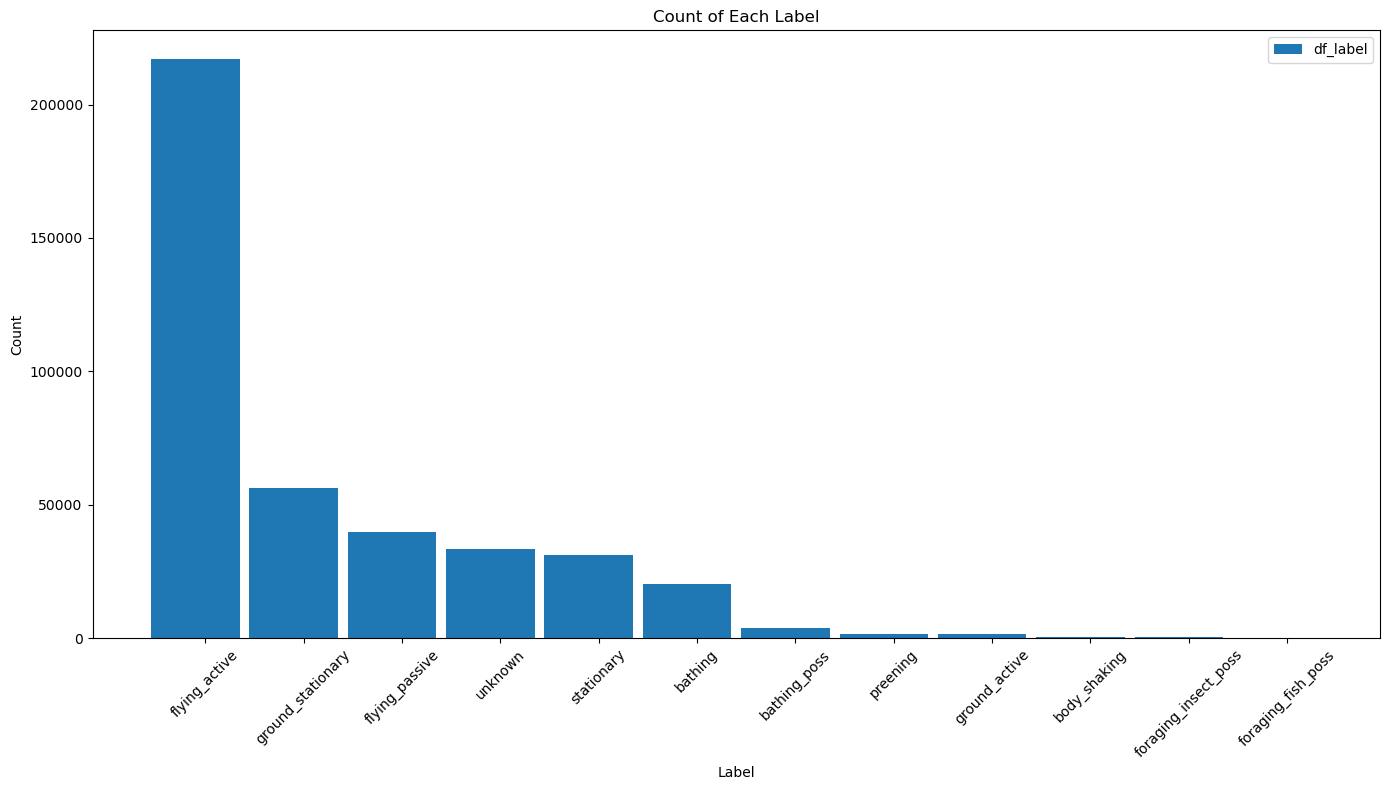

In [21]:
# Count the number of each unique value in the 'label' column
label_counts = selected_df['label'].value_counts()

# Create a DataFrame to hold the counts for df_2018, df_2019, and df_2022
combined_counts = pd.DataFrame({
    'df_label': label_counts
}).fillna(0)

# Plot a bar chart with three bars for each label
labels = combined_counts.index
x = np.arange(len(labels))  # the label locations
width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(14, 8))
bars1 = ax.bar(x - width, combined_counts['df_label'], 1-width, label='df_label')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_title('Count of Each Label')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()

fig.tight_layout()
plt.show()

In [22]:
label_dict = {
    'ground_stationary': 0,  #  if a bird is resting on the ground, including standing
    'ground_active': 0,
    'stationary': 1,  #  if a bird is resting on the sea surface
    'preening': 1,
    'bathing': 2,
    'bathing_poss': 2,
    'body_shaking': 2,
    'flying_active': 3,  # flying active -> flapping
    'flying_passive': 4,  # flying passive -> flying without flapping, including gliding
    'foraging': 5,
    'poss_foraging': 5,
    'foraging_fish_poss': 5,
    'foraging_insect_poss': 5,
    'forgaing_insect': 5,
    'foraging_non-fish': 5,
    'foraging_steal': 5,
    'foraging_poss': 5,
    'foraging_dive': 5,
    'unknown': -2,  #-1
}

labeldict_findstr = {-2:'unknown',
                     0:'ground_stationary',
                     1:'stationary',
                     2:'bathing',
                     3:'flying_active',
                     4:'flying_passive',
                     5:'foraging'}

selected_df['label_id'] = selected_df['label'].map(label_dict)
selected_df['label_id'] = selected_df['label_id'].fillna(-2)
 
device = 'cuda'
len_sw = 50
sensor_type = 'accel'

activity_label = True
if activity_label:
    selected_columns = ['acc_x', 'acc_y', 'acc_z', 'label_id', 'back']  # without timestamps
  # without timestamps，activity labels
else:
    # selected_df['animal_tag_id'] = pd.factorize(selected_df['animal_tag'])[0]
    selected_columns = ['acc_x', 'acc_y', 'acc_z', 'file_id', 'label_id']  # without timestamps
  # 将animal tag作为label，判断鸟的embedding是否分开

selected_np = selected_df[selected_columns].values

############################################
data_np = selected_np[:, :-2]
tmp_b_stand = gaussian_std(data_np)
##########################################

selected_np[:, :-2] = tmp_b_stand

tmp_b = sliding_window(selected_np[:, :-1], len_sw, len_sw)
# concatenate list
data_b = np.transpose(tmp_b[:, :, :-1], (0, 2, 1))  # [B, Len, dim-1] -> [B, dim-1, Len]
label_b = tmp_b[:, :, -1]  # [B, Len]

batch_size = 1024
train_set_r = data_loader_umineko(data_b.astype(float), label_b.astype(int), device=device)
train_loader = DataLoader(train_set_r, batch_size=batch_size,
                          shuffle=False, drop_last=False)


In [23]:
model = Autoencoder3d()
model = model.to(device)

full_model_path = r'D:\code\DeepView\deepview\calculate_results\data\umineko\AE_reconstruct_epoch623_datalen50_accel.pth'
if torch.cuda.is_available():
    model.load_state_dict(torch.load(full_model_path, weights_only=False))
else:
    model.load_state_dict(torch.load(full_model_path, weights_only=False, map_location=torch.device('cpu')))


In [24]:
representation_list, sample_list, pred_list, label_list = \
            AE_eval_time_series(train_loader, model, device)
repre_concat = np.concatenate(representation_list)
repre_reshape = repre_concat.reshape(repre_concat.shape[0], -1)
    
umap_3d = UMAP(n_components=3)
proj_3d_gyro = umap_3d.fit_transform(repre_reshape)

label_concat = np.concatenate(label_list)
label_concat_vote = majority_value(label_concat)

label_concat_vote_str = [labeldict_findstr[i] for i in label_concat_vote]

fig_3d = px.scatter_3d(
    proj_3d_gyro, x=0, y=1, z=2,
    color=label_concat_vote_str,
    labels={'color': 'device location'},
    color_discrete_map={'unknown': 'lightgrey'},
)
# Reduce marker size for all points
for trace in fig_3d.data:
    trace.marker.size = 6  # Adjust the size to your preference (e.g., 6)

# Update transparency for traces where activity is '-2.0'
fig_3d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())
fig_3d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point
fig_3d.write_html("3d-623-back1-label.html")

#############################################################
umap_2d = UMAP(n_components=2)
proj_2d_gyro = umap_2d.fit_transform(repre_reshape)
fig_2d = px.scatter(
    proj_2d_gyro, x=0, y=1,
    color=label_concat_vote_str,
    labels={'color': 'device location'},
    color_discrete_map={'unknown': 'lightgrey'},
)
# Reduce marker size for all points
for trace in fig_2d.data:
    trace.marker.size = 6 
    
# Update transparency for traces where activity is '-2.0'
fig_2d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())
fig_2d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point
fig_2d.write_html("2dt-623-back1-label.html")
